In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

trip_df = pd.read_csv('../data/processed/trip_level_cleaned.csv')
trip_df.shape

(14787, 38)

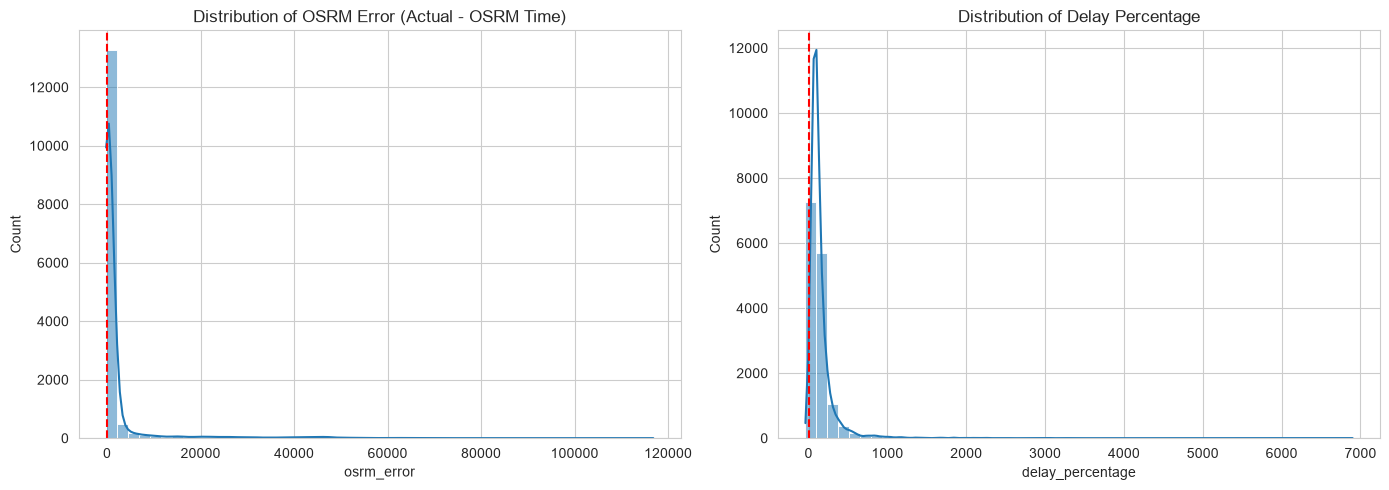

In [2]:
# Overall Delay Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(trip_df['osrm_error'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of OSRM Error (Actual - OSRM Time)')
axes[0].axvline(0, color='red', linestyle='--')

sns.histplot(trip_df['delay_percentage'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Delay Percentage')
axes[1].axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

In [3]:
print("OSRM Error Stats:")
print(trip_df['osrm_error'].describe())

print("\nDelay % Stats:")
print(trip_df['delay_percentage'].describe())

print("\n% trips delayed (delay_flag=1):", round(trip_df['delay_flag'].mean() * 100, 2), "%")

OSRM Error Stats:
count     14787.00000
mean       1986.66714
std        7450.46200
min        -207.00000
25%          64.00000
50%         173.00000
75%         545.00000
max      116838.00000
Name: osrm_error, dtype: float64

Delay % Stats:
count    14787.000000
mean       146.230257
std        197.029124
min        -39.583333
25%         66.666667
50%        100.000000
75%        159.375000
max       6900.000000
Name: delay_percentage, dtype: float64

% trips delayed (delay_flag=1): 96.23 %


C:\Users\lenovo\AppData\Local\Temp\ipykernel_5344\5948706.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delay_labels, y=delay_counts.values, ax=axes[0], palette=['#1C7293', '#F2994A'])


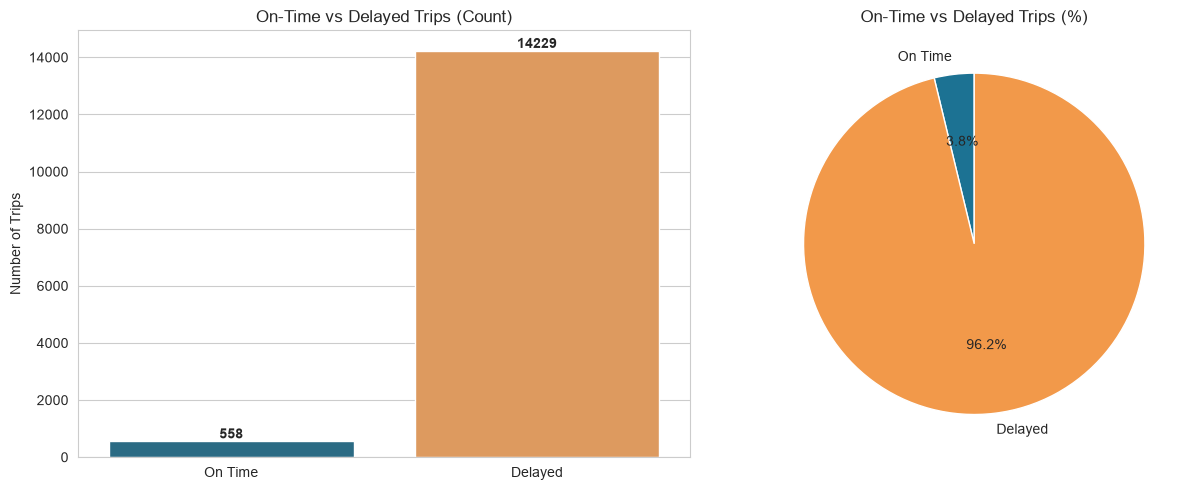

Total Trips: 14787
On-Time: 558 (3.77%)
Delayed: 14229 (96.23%)


In [4]:
# On-Time vs Delayed Split
delay_counts = trip_df['delay_flag'].value_counts().sort_index()  
delay_labels = ['On Time', 'Delayed']  

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(x=delay_labels, y=delay_counts.values, ax=axes[0], palette=['#1C7293', '#F2994A'])
axes[0].set_title('On-Time vs Delayed Trips (Count)')
axes[0].set_ylabel('Number of Trips')
for i, v in enumerate(delay_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

axes[1].pie(delay_counts.values, labels=delay_labels, autopct='%1.1f%%', 
            colors=['#1C7293', '#F2994A'], startangle=90)
axes[1].set_title('On-Time vs Delayed Trips (%)')

plt.tight_layout()
plt.show()

print(f"Total Trips: {len(trip_df)}")
print(f"On-Time: {delay_counts[0]} ({round(delay_counts[0]/len(trip_df)*100, 2)}%)")
print(f"Delayed: {delay_counts[1]} ({round(delay_counts[1]/len(trip_df)*100, 2)}%)")

  route_type  total_trips  avg_delay_pct  delay_rate  avg_actual_time  \
0    Carting         8906         165.62       95.22       358.383786   
1        FTL         5881         116.87       97.76      9714.636796   

   avg_osrm_time  
0     154.477319  
1    5028.213399  


C:\Users\lenovo\AppData\Local\Temp\ipykernel_5344\3258909449.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=trip_df, x='route_type', y='delay_percentage', ax=axes[0], palette=['#1C7293', '#F2994A'])


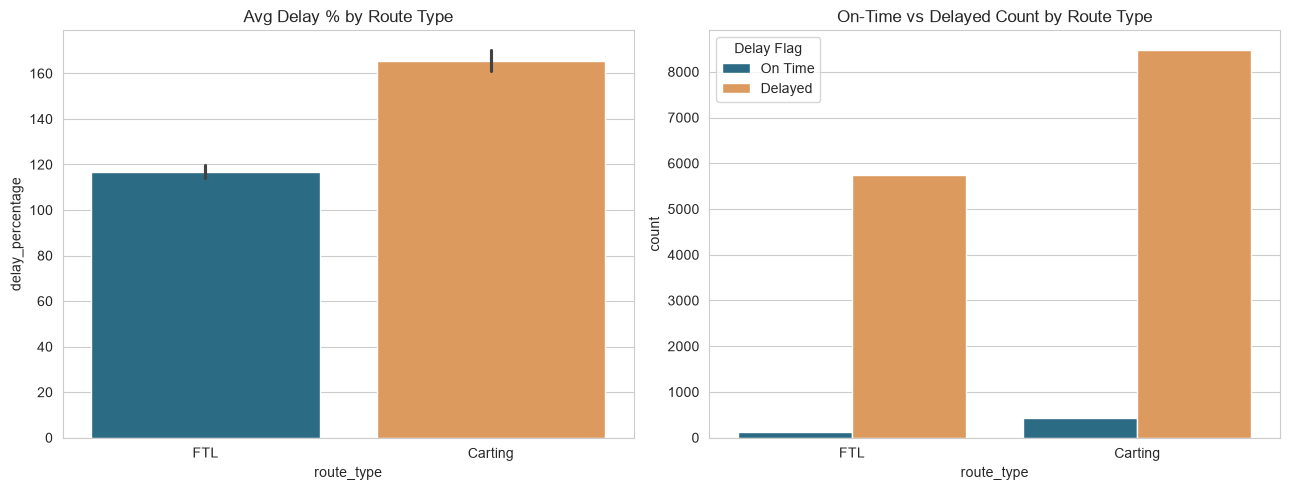

In [5]:
# Route Type Comparison (FTL vs Carting) 
route_summary = trip_df.groupby('route_type').agg(
    total_trips=('trip_uuid', 'count'),
    avg_delay_pct=('delay_percentage', 'mean'),
    delay_rate=('delay_flag', 'mean'),
    avg_actual_time=('actual_time', 'mean'),
    avg_osrm_time=('osrm_time', 'mean')
).reset_index()

route_summary['delay_rate'] = round(route_summary['delay_rate'] * 100, 2)
route_summary['avg_delay_pct'] = round(route_summary['avg_delay_pct'], 2)
print(route_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=trip_df, x='route_type', y='delay_percentage', ax=axes[0], palette=['#1C7293', '#F2994A'])
axes[0].set_title('Avg Delay % by Route Type')

sns.countplot(data=trip_df, x='route_type', hue='delay_flag', ax=axes[1], palette=['#1C7293', '#F2994A'])
axes[1].set_title('On-Time vs Delayed Count by Route Type')
axes[1].legend(title='Delay Flag', labels=['On Time', 'Delayed'])

plt.tight_layout()
plt.show()

                           corridor_id  total_trips  avg_delay_pct  delay_rate
103                     Nagaland_Assam            5         400.89      100.00
60   Himachal Pradesh_Himachal Pradesh           18         351.27       94.44
62     Jammu & Kashmir_Jammu & Kashmir           13         291.25      100.00
144        Uttar Pradesh_Uttar Pradesh          544         267.01       92.28
155            West Bengal_West Bengal          610         239.30       99.18
15                         Bihar_Bihar          342         232.80      100.00
140                Uttar Pradesh_Delhi           77         229.49       98.70
84       Madhya Pradesh_Madhya Pradesh          251         226.71       99.20
7                          Assam_Assam          215         212.35       90.70
65                 Jharkhand_Jharkhand          143         209.08       97.90


C:\Users\lenovo\AppData\Local\Temp\ipykernel_5344\26323093.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_worst, x='avg_delay_pct', y='corridor_id', palette='Oranges_r')


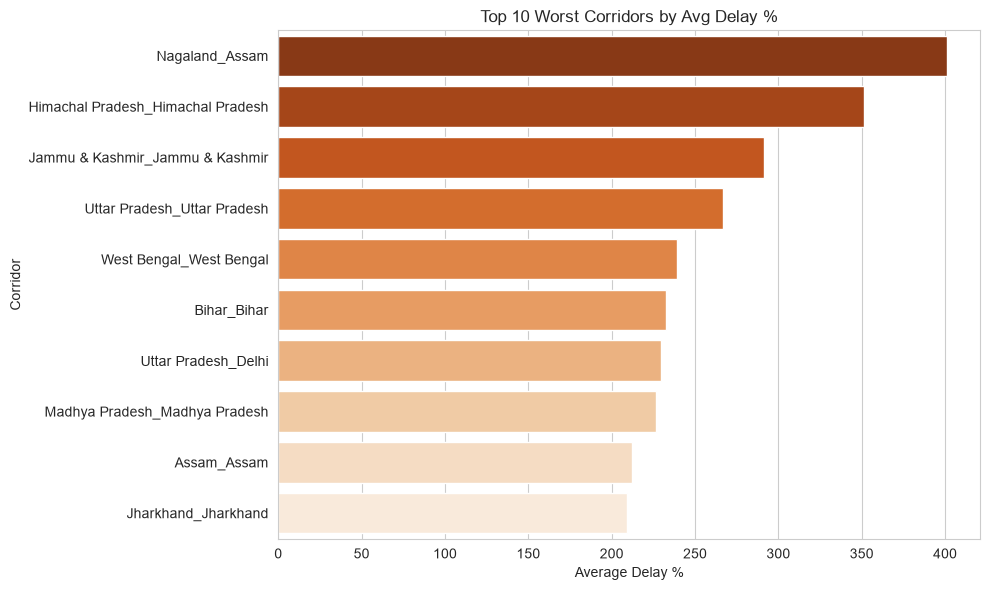

In [6]:
# Corridor-wise Analysis (Top 10 Worst) 

corridor_summary = trip_df.groupby('corridor_id').agg(
    total_trips=('trip_uuid', 'count'),
    avg_delay_pct=('delay_percentage', 'mean'),
    delay_rate=('delay_flag', 'mean')
).reset_index()

# Filter corridors with meaningful volume (avoid 1-2 trip corridors skewing results)
corridor_summary = corridor_summary[corridor_summary['total_trips'] >= 5]
corridor_summary['avg_delay_pct'] = round(corridor_summary['avg_delay_pct'], 2)
corridor_summary['delay_rate'] = round(corridor_summary['delay_rate'] * 100, 2)

top10_worst = corridor_summary.sort_values('avg_delay_pct', ascending=False).head(10)
print(top10_worst)

plt.figure(figsize=(10, 6))
sns.barplot(data=top10_worst, x='avg_delay_pct', y='corridor_id', palette='Oranges_r')
plt.title('Top 10 Worst Corridors by Avg Delay %')
plt.xlabel('Average Delay %')
plt.ylabel('Corridor')
plt.tight_layout()
plt.show()

  is_interstate  total_trips  avg_delay_pct  delay_rate
0    Intrastate        11759         156.13       95.92
1    Interstate         3028         107.78       97.42


C:\Users\lenovo\AppData\Local\Temp\ipykernel_5344\1184184114.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=interstate_summary, x='is_interstate', y='avg_delay_pct', palette=['#1C7293', '#F2994A'])


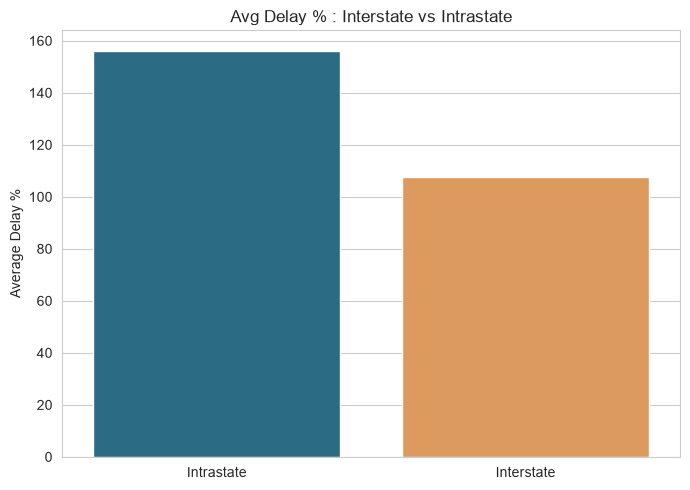

In [7]:
# Interstate vs Intrastate Delay
interstate_summary = trip_df.groupby('is_interstate').agg(
    total_trips=('trip_uuid', 'count'),
    avg_delay_pct=('delay_percentage', 'mean'),
    delay_rate=('delay_flag', 'mean')
).reset_index()

interstate_summary['avg_delay_pct'] = round(interstate_summary['avg_delay_pct'], 2)
interstate_summary['delay_rate'] = round(interstate_summary['delay_rate'] * 100, 2)
interstate_summary['is_interstate'] = interstate_summary['is_interstate'].map({True: 'Interstate', False: 'Intrastate'})

print(interstate_summary)

plt.figure(figsize=(7, 5))
sns.barplot(data=interstate_summary, x='is_interstate', y='avg_delay_pct', palette=['#1C7293', '#F2994A'])
plt.title('Avg Delay % : Interstate vs Intrastate')
plt.ylabel('Average Delay %')
plt.xlabel('')
plt.tight_layout()
plt.show()

  distance_category  total_trips  avg_delay_pct  delay_rate
0           0-100km         6412         180.80       94.67
1         100-300km         3274         138.21       94.99
2         300-600km         1991         118.77       98.09
3            600+km         3110         100.98       99.55


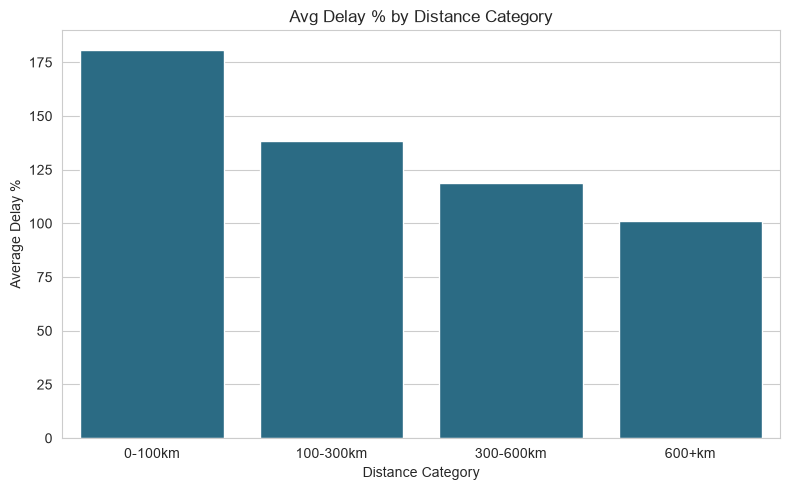

In [8]:
# Distance Category vs Delay

distance_summary = trip_df.groupby('distance_category', observed=True).agg(
    total_trips=('trip_uuid', 'count'),
    avg_delay_pct=('delay_percentage', 'mean'),
    delay_rate=('delay_flag', 'mean')
).reset_index()

distance_summary['avg_delay_pct'] = round(distance_summary['avg_delay_pct'], 2)
distance_summary['delay_rate'] = round(distance_summary['delay_rate'] * 100, 2)

print(distance_summary)

plt.figure(figsize=(8, 5))
sns.barplot(data=distance_summary, x='distance_category', y='avg_delay_pct', color='#1C7293')
plt.title('Avg Delay % by Distance Category')
plt.ylabel('Average Delay %')
plt.xlabel('Distance Category')
plt.tight_layout()
plt.show()

    day_name  total_trips  avg_delay_pct
1     Monday         1980         147.57
5    Tuesday         2035         144.53
6  Wednesday         2731         149.46
4   Thursday         2103         144.55
0     Friday         2057         149.40
2   Saturday         2128         152.04
3     Sunday         1753         132.90


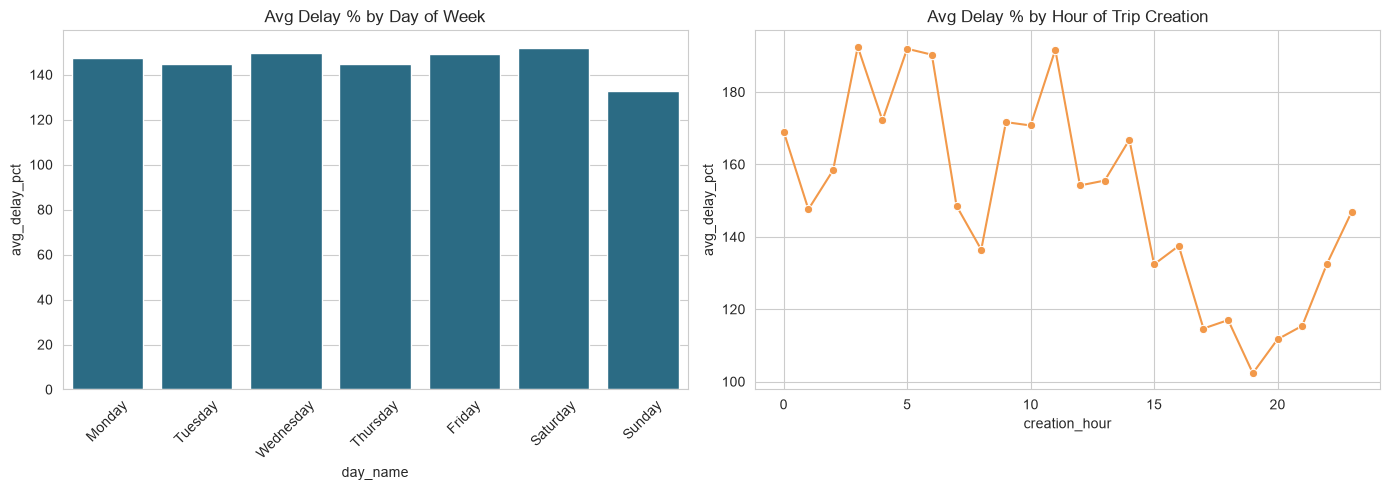

In [9]:
# Time-Based Patterns (Day of Week / Weekend / Hour)
trip_df['trip_creation_time'] = pd.to_datetime(trip_df['trip_creation_time'])
trip_df['day_name'] = trip_df['trip_creation_time'].dt.day_name()
trip_df['creation_hour'] = trip_df['trip_creation_time'].dt.hour

day_summary = trip_df.groupby('day_name').agg(
    total_trips=('trip_uuid', 'count'),
    avg_delay_pct=('delay_percentage', 'mean')
).reset_index()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_summary['day_name'] = pd.Categorical(day_summary['day_name'], categories=day_order, ordered=True)
day_summary = day_summary.sort_values('day_name')
day_summary['avg_delay_pct'] = round(day_summary['avg_delay_pct'], 2)

print(day_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=day_summary, x='day_name', y='avg_delay_pct', ax=axes[0], color='#1C7293')
axes[0].set_title('Avg Delay % by Day of Week')
axes[0].tick_params(axis='x', rotation=45)

hour_summary = trip_df.groupby('creation_hour').agg(avg_delay_pct=('delay_percentage', 'mean')).reset_index()
sns.lineplot(data=hour_summary, x='creation_hour', y='avg_delay_pct', ax=axes[1], marker='o', color='#F2994A')
axes[1].set_title('Avg Delay % by Hour of Trip Creation')

plt.tight_layout()
plt.show()

    source_center source_city_code   source_state  total_trips  avg_delay_pct  \
300  IND395009AAA            Surat        Gujarat           13         825.03   
137  IND211002AAB        Allahabad  Uttar Pradesh           43         818.99   
362  IND416510AAA       Sawantwadi    Maharashtra           16         659.78   
700  IND700028AAB              CCU    West Bengal           11         603.31   
446  IND500008AAC        Hyderabad      Telangana           14         534.31   
804  IND786181AAC       Margherita          Assam           22         484.31   
702  IND700065AAA              CCU    West Bengal           26         475.37   
703  IND700065AAB              CCU    West Bengal           15         463.13   
2    IND000000ABG        Hyderabad      Telangana           11         426.21   
24   IND110064AAA            Delhi          Delhi           42         397.28   

     delay_rate  
300      100.00  
137      100.00  
362      100.00  
700      100.00  
446      100.00  


C:\Users\lenovo\AppData\Local\Temp\ipykernel_5344\3610810854.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_worst_hubs, x='avg_delay_pct', y='source_city_code', palette='Reds_r')


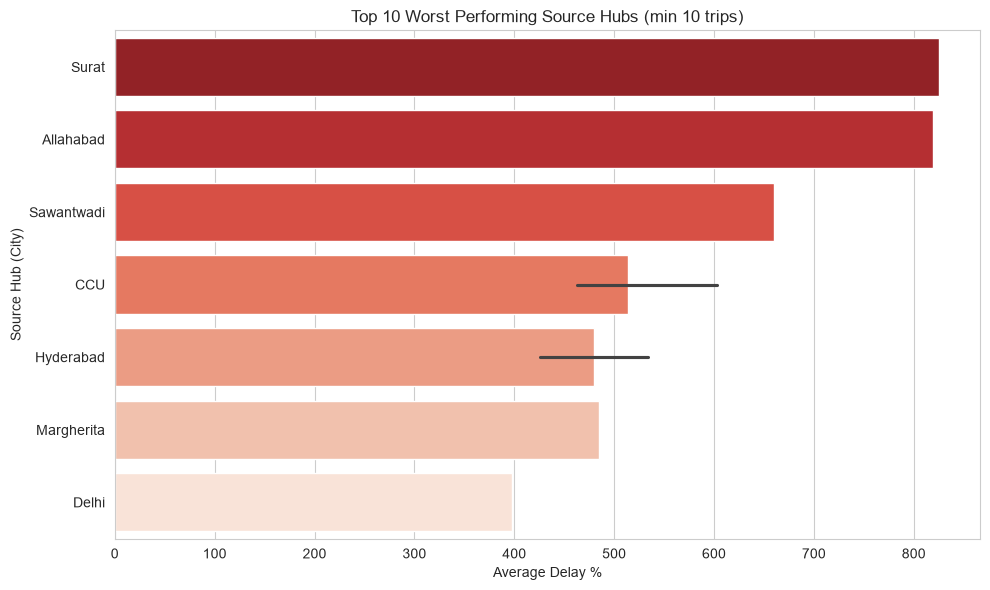

In [10]:
# Hub-wise Performance

# Source hub performance
hub_summary = trip_df.groupby(['source_center', 'source_city_code', 'source_state']).agg(
    total_trips=('trip_uuid', 'count'),
    avg_delay_pct=('delay_percentage', 'mean'),
    delay_rate=('delay_flag', 'mean')
).reset_index()

hub_summary = hub_summary[hub_summary['total_trips'] >= 10]  # meaningful volume only
hub_summary['avg_delay_pct'] = round(hub_summary['avg_delay_pct'], 2)
hub_summary['delay_rate'] = round(hub_summary['delay_rate'] * 100, 2)

top10_worst_hubs = hub_summary.sort_values('avg_delay_pct', ascending=False).head(10)
print(top10_worst_hubs)

plt.figure(figsize=(10, 6))
sns.barplot(data=top10_worst_hubs, x='avg_delay_pct', y='source_city_code', palette='Reds_r')
plt.title('Top 10 Worst Performing Source Hubs (min 10 trips)')
plt.xlabel('Average Delay %')
plt.ylabel('Source Hub (City)')
plt.tight_layout()
plt.show()

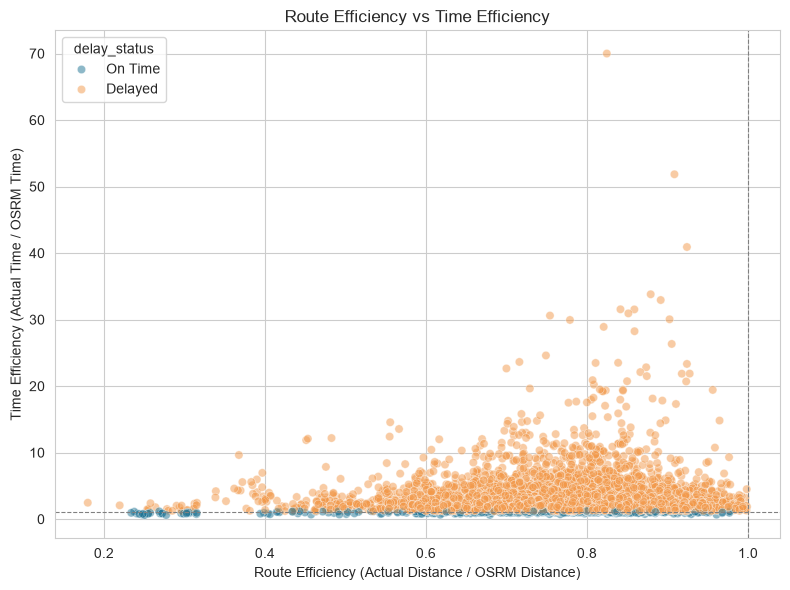

                  route_efficiency  time_efficiency
route_efficiency           1.00000         -0.01016
time_efficiency           -0.01016          1.00000


In [12]:
# Route Efficiency vs Time Efficiency Correlation
trip_df['delay_status'] = trip_df['delay_flag'].map({0: 'On Time', 1: 'Delayed'})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=trip_df, x='route_efficiency', y='time_efficiency', 
                 hue='delay_status', hue_order=['On Time', 'Delayed'],
                 palette={'On Time': '#1C7293', 'Delayed': '#F2994A'}, alpha=0.5)
plt.title('Route Efficiency vs Time Efficiency')
plt.xlabel('Route Efficiency (Actual Distance / OSRM Distance)')
plt.ylabel('Time Efficiency (Actual Time / OSRM Time)')
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(1, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

correlation = trip_df[['route_efficiency', 'time_efficiency']].corr()
print(correlation)

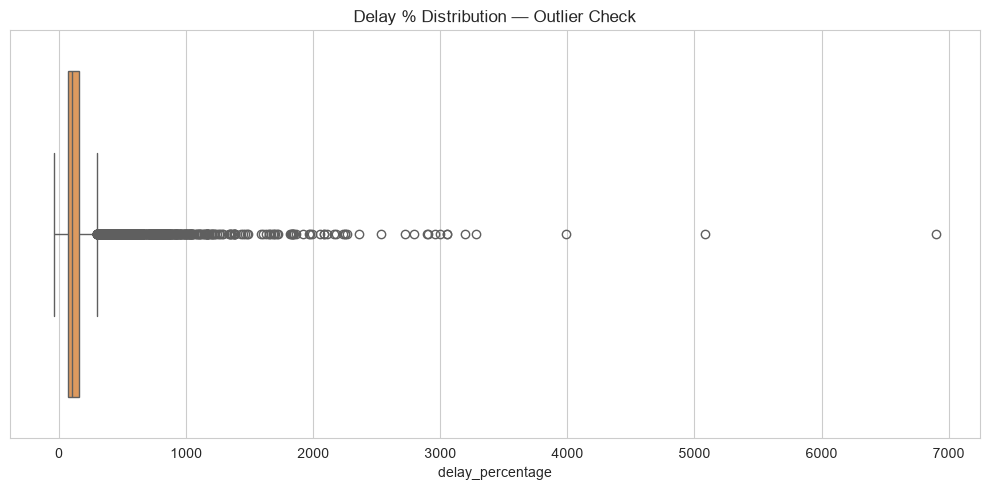

Extreme delay threshold (99th percentile): 896.57%
Number of extreme trips: 148


,trip_uuid,corridor_id,route_type,delay_percentage
1807,trip-153691774924973666,Gujarat_Gujarat,Carting,6900.000000
1023,trip-153682944027974510,Uttar Pradesh_Uttar Pradesh,Carting,5084.615385
3089,trip-153706705984334815,Uttar Pradesh_Uttar Pradesh,Carting,3991.071429
12011,trip-153819027212623807,Uttar Pradesh_Uttar Pradesh,Carting,3280.487805
2801,trip-153704259509954539,Assam_Assam,Carting,3193.750000
13618,trip-153843860882255800,Jharkhand_Jharkhand,Carting,3054.545455
3742,trip-153715769059710902,Maharashtra_Maharashtra,Carting,3052.666667
6648,trip-153750335607956765,Maharashtra_Maharashtra,Carting,2993.464052
8648,trip-153775088157458469,West Bengal_West Bengal,Carting,2960.000000
11338,trip-153809667984245845,Madhya Pradesh_Madhya Pradesh,Carting,2904.347826


In [13]:
# Outlier Detection
plt.figure(figsize=(10, 5))
sns.boxplot(data=trip_df, x='delay_percentage', color='#F2994A')
plt.title('Delay % Distribution — Outlier Check')
plt.tight_layout()
plt.show()

# Extreme delay trips (top 1%)
threshold = trip_df['delay_percentage'].quantile(0.99)
extreme_trips = trip_df[trip_df['delay_percentage'] > threshold]
print(f"Extreme delay threshold (99th percentile): {round(threshold, 2)}%")
print(f"Number of extreme trips: {len(extreme_trips)}")
extreme_trips[['trip_uuid', 'corridor_id', 'route_type', 'delay_percentage']].sort_values('delay_percentage', ascending=False).head(10)

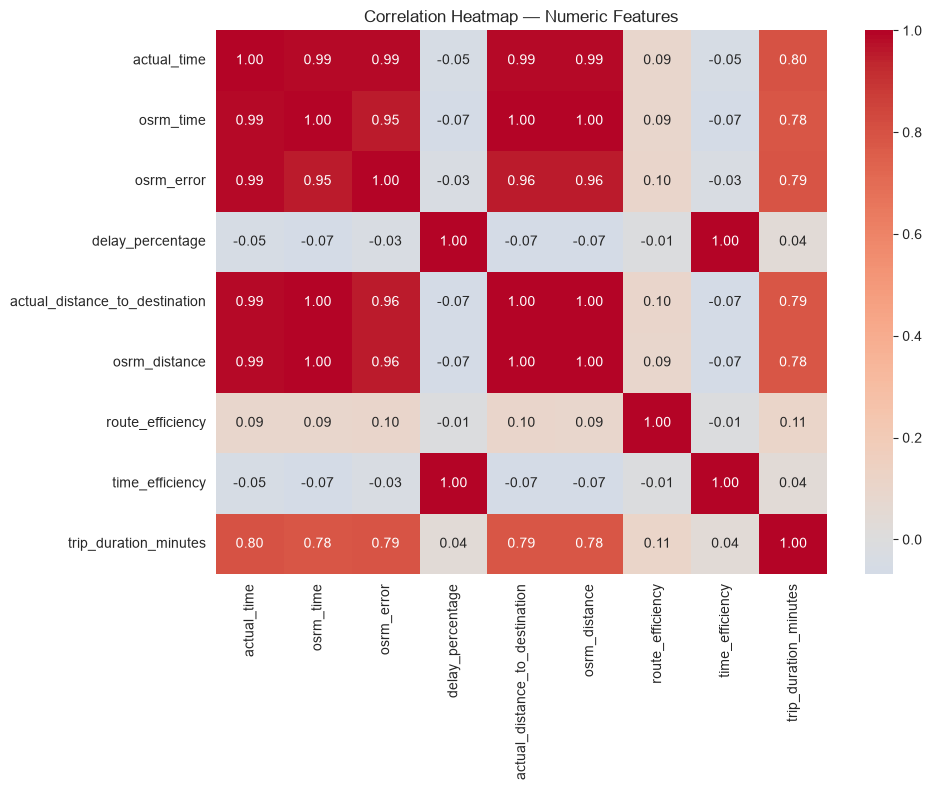

In [14]:
# Correlation Heatmap
numeric_cols = ['actual_time', 'osrm_time', 'osrm_error', 'delay_percentage', 
                 'actual_distance_to_destination', 'osrm_distance', 
                 'route_efficiency', 'time_efficiency', 'trip_duration_minutes']

plt.figure(figsize=(10, 8))
corr_matrix = trip_df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()